# DX 601 Final Project

## Introduction

In this project, you will practice all the skills that you have learned throughout this module.
You will pick a data set to analyze from a list provided, and then perform a variety of analysis.
Most of the problems and questions are open ended compared to your previous homeworks, and you will be asked to explain your choices.
Most of them will have a particular type of solution implied, but it is up to you to figure out the details based on what you have learned in this module.

## Instructions

Each problem asks you to perform some analysis of the data, and usually answer some questions about the results.
Make sure that your question answers are well supported by your analysis and explanations; simply stating an answer without support will earn minimal points.

Notebook cells for code and text have been added for your convenience, but feel free to add additional cells.

## Example Code

You may find it helpful to refer to this GitHub repository of Jupyter notebooks for example code.

* https://github.com/bu-cds-omds/dx500-examples
* https://github.com/bu-cds-omds/dx601-examples
* https://github.com/bu-cds-omds/dx602-examples

Any calculations demonstrated in code examples or videos may be found in these notebooks, and you are allowed to copy this example code in your homework answers.

## Submission

To submit your homework, take the following steps.

1. Save and commit this notebook.
2. Push your changes to GitHub.
3. Confirm that your changes are visible in GitHub.
4. Delete the codespace to avoid wasting your free quota.

This project will be entirely manually graded.
However, we may rerun some or all of your code to confirm that it works as described.

### Late Policy

The normal homework late policy for OMDS does not apply to this project.
Boston University requires final grades to be submitted within 72 hours of class instruction ending, so we cannot accommodate 5 days of late submissions.

However, we have delayed the due date of this project to be substantially later than necessary given its scope, and given you more days for submission with full credit than you would have had days for submission with partial credit under the homework late policy.
Finally, the deadlines for DX 601 and DX 602 were coordinated to be a week apart while giving ample time for both of their projects.

## Shared Imports

For this project, you are forbidden to use modules that were not loaded in this template.
While other modules are handy in practice, modules that trivialize these problems interfere with our assessment of your own knowledge and skills.

If you believe a module covered in the course material (not live sessions) is missing, please check with your learning facilitator.

In [1]:
import math
import sys

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.stats
import sklearn.linear_model

from sklearn.decomposition import PCA

## Problems

### Problem 1 (5 points)

Pick one of the following data sets to analyze in this project.
Load the data set, and show a random sample of 10 rows.

* [Iris data set](https://archive.ics.uci.edu/dataset/53/iris) ([PMLB copy](https://github.com/EpistasisLab/pmlb/tree/master/datasets/iris))
* [Breast Cancer Wisconsin](https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic) ([PMLB copy](https://github.com/EpistasisLab/pmlb/tree/master/datasets/_deprecated_breast_cancer_wisconsin))
* [Wine Quality](https://archive.ics.uci.edu/dataset/186/wine+quality) ([PMLB - white subset only](https://github.com/EpistasisLab/pmlb/tree/master/datasets/wine_quality_white))


The PMLB copies of the data are generally cleaner and recommended for this project, but the other links are provided to give you more context.
To load the data from the PMLB Github repository, navigate to the `.tsv.gz` file in GitHub and copy the link from the "Raw" button.

If the data set you choose has more than ten columns, you may limit later analysis that is requested per column to just the first ten columns.

In [3]:
# YOUR CODE HERE

iris = pd.read_csv("iris.tsv", sep='\t')
iris.head(10)

,sepal-length,sepal-width,petal-length,petal-width,target
0,6.7,3.0,5.2,2.3,2
1,6.0,2.2,5.0,1.5,2
2,6.2,2.8,4.8,1.8,2
3,7.7,3.8,6.7,2.2,2
4,7.2,3.0,5.8,1.6,2
5,5.5,2.4,3.8,1.1,1
6,6.0,2.7,5.1,1.6,1
7,5.5,2.5,4.0,1.3,1
8,5.6,2.9,3.6,1.3,1
9,5.7,2.9,4.2,1.3,1


This is the loaded dataset with 10 samples. The dataset has 5 columns - sepal-lenth, sepal-width, petal-length, petal-width, and target.

### Problem 2 (10 points)

List all the columns in the data set, and describe each of them in your own words.
You may have to search to learn about the data set columns, but make sure that the descriptions are your own words.

In [4]:
# YOUR CODE HERE

iris.columns

Index(['sepal-length', 'sepal-width', 'petal-length', 'petal-width', 'target'], dtype='object')

The sepal length is the distance from the base to the tip of the sepal, which are the green, leaf-like structures that enclose the flower bud.
The sepal sepal width is the maximum breadth of the sepal.
The petal length is the length of the petal, which is the colorful inner part of the flower.
The petal width is he maximum breadth of the petal.

### Problem 3 (15 points)

Plot histograms of each column.
For each column, state the distribution covered in this module that you think best matches that column.

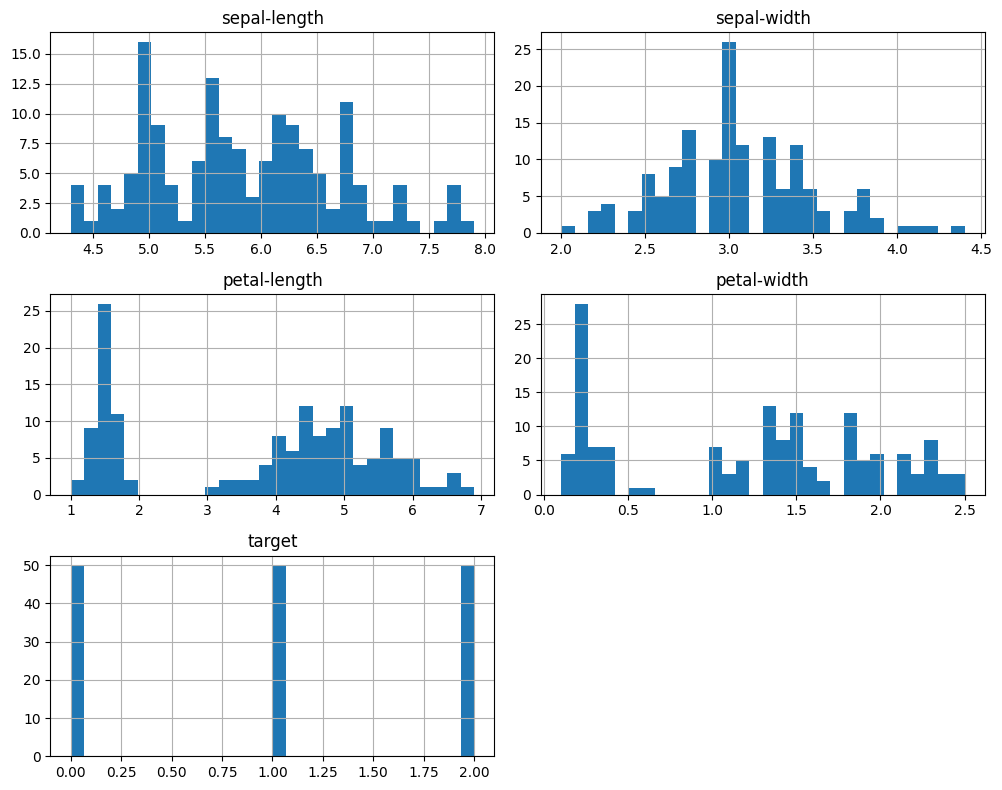

In [13]:
# YOUR CODE HERE

df = pd.DataFrame(iris)

df.hist(figsize=(10, 8), bins=30)
plt.tight_layout()
plt.show()

The sepal length is a Normal Distribution. The sepal width is a Normal Distribution. The petal length is a Normal Distribution. The petal width is a Normal Distrubtion. THe petal width is a Normal Distribution. The target is a Categorial Distribution.

### Problem 4 (20 points)

Plot each pair of an input column and the output column.
Classify each pair of input column and the output column as being independent or not.
Describe in words why you think that was the case.

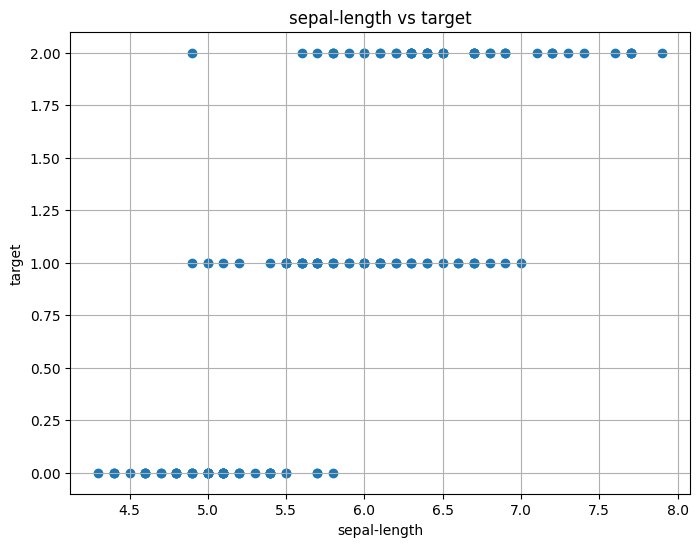

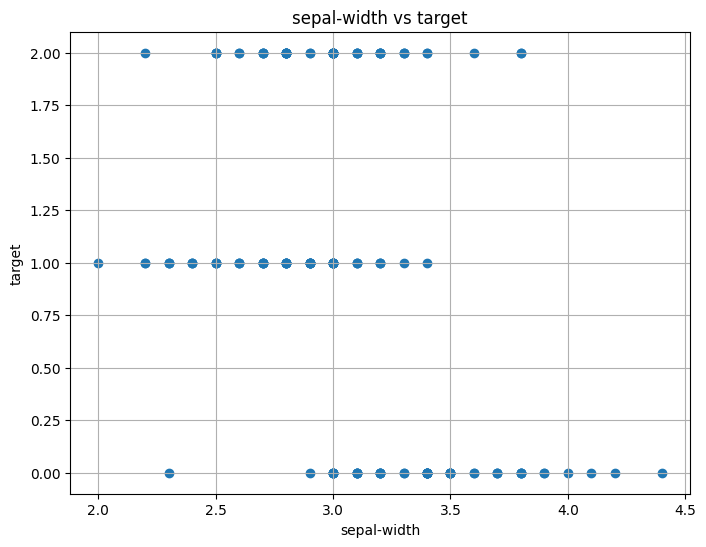

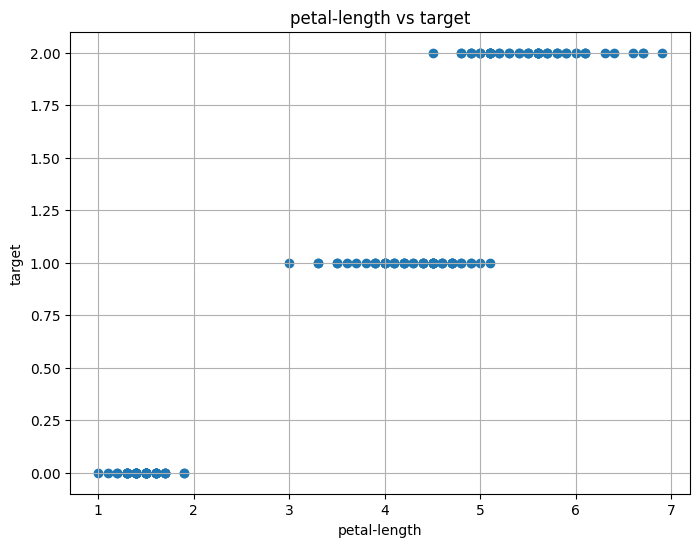

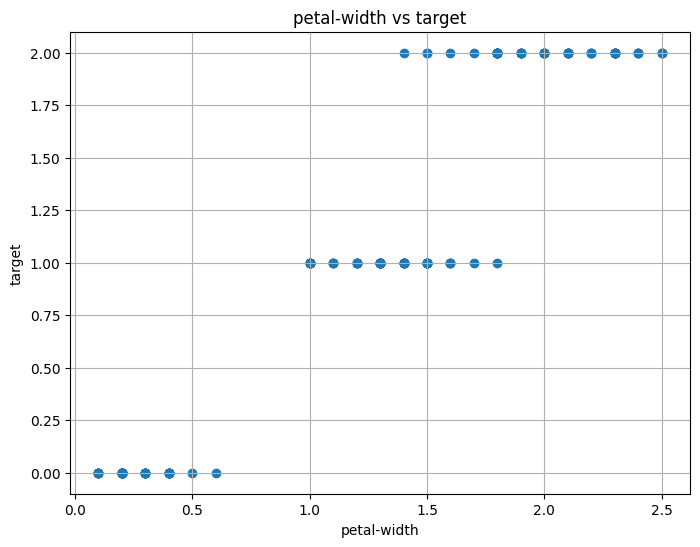

In [14]:
# YOUR CODE HERE

df = pd.DataFrame(iris)

# Input columns (all columns except 'target')
input_columns = [col for col in df.columns if col != 'target']
output_column = 'target'

# Plot each input column against the target column
for col in input_columns:
    plt.figure(figsize=(8, 6)) # Create a new figure for each plot
    plt.scatter(df[col], df[output_column])
    plt.title(f'{col} vs {output_column}')
    plt.xlabel(col)
    plt.ylabel(output_column)
    plt.grid(True)
    plt.show()

The sepal length and target are not independent.
This relationship suggests that sepal length is a strong predictor of the target class. 

The sepal width and target are not independent.
The width measurements tend to align with the target variable.

The petal length and target is not independent.
The petal length appears to be highly correlated with the target variable.

The petal width and target is not independent.
The petal width also shows a strong relationship with the target column.

### Problem 5 (20 points)

Build an ordinary least squares regression for the target using all the input columns.
Report the average loss of the model over the whole data set.
Plot the actual values vs the predicted outputs to compare them. 

Average Loss (Mean Squared Error): 0.0464


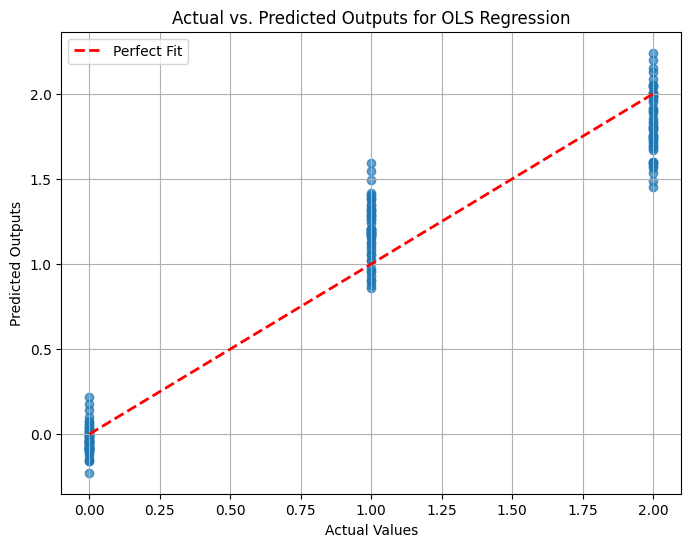

In [15]:
# YOUR CODE HERE

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

df = pd.DataFrame(iris)

# Define features (X) and target (y)
X = df[['sepal-length', 'sepal-width', 'petal-length', 'petal-width']]
y = df['target']

# 2. Build the OLS Regression Model
model = LinearRegression()
model.fit(X, y)

# Make predictions
y_pred = model.predict(X)

# 3. Report the average loss (Mean Squared Error)
average_loss = mean_squared_error(y, y_pred)
print(f"Average Loss (Mean Squared Error): {average_loss:.4f}")

# 4. Plot actual vs. predicted values
plt.figure(figsize=(8, 6))
plt.scatter(y, y_pred, alpha=0.7)
plt.plot([min(y), max(y)], [min(y), max(y)], 'r--', lw=2, label='Perfect Fit') # Add a perfect fit line
plt.xlabel("Actual Values")
plt.ylabel("Predicted Outputs")
plt.title("Actual vs. Predicted Outputs for OLS Regression")
plt.grid(True)
plt.legend()
plt.show()

The average loss, represented by the Mean Squared Error (MSE), quantifies the average squared difference between the actual target values and the model's predictions. A lower MSE indicates a better fit of the model to the data.

### Problem 6 (20 points)

Which input column gives the best linear model of the target on its own?
How does that model compare to the model in problem 5?


In [17]:
# YOUR CODE HERE

df = pd.DataFrame(iris)

# Calculate Pearson correlation coefficient for each input column with the target
correlations = {}
for col in ['sepal-length', 'sepal-width', 'petal-length', 'petal-width']:
    correlations[col] = df[col].corr(df['target'])

# Find the column with the highest absolute correlation
best_column = None
max_abs_corr = -1

for col, corr_val in correlations.items():
    if abs(corr_val) > max_abs_corr:
        max_abs_corr = abs(corr_val)
        best_column = col

print("Correlation coefficients with 'target':")
print(correlations)
print(f"\nThe input column that gives the best linear model of the target on its own is: {best_column}")

Correlation coefficients with 'target':
{'sepal-length': np.float64(0.7825612318100816), 'sepal-width': np.float64(-0.41944620026002755), 'petal-length': np.float64(0.9490425448523345), 'petal-width': np.float64(0.9564638238016161)}

The input column that gives the best linear model of the target on its own is: petal-width


The input column that gives the best linear model on the target is the petal width. In problem 5, we get the average loss.

### Problem 7 (20 points)

Pick and plot a pair of input columns with a visible dependency.
Identify a split of the values of one column illustrating the dependency and plot histograms of the other variable on both sides of the split.
That is, pick a threshold $t$ for one column $x$ and make two histograms, one where $x < t$ and one where $x \geq t$.

These histograms should look significantly different to make the dependency clear.
There should be enough data in both histograms so that these differences are unlikely to be noise.
Also make sure that the horizontal axis is the same in both histograms for clarity.

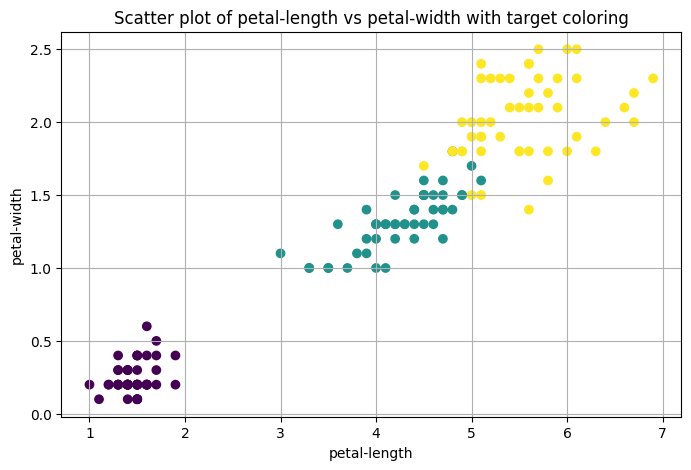

The scatter plot shows a clear dependency: as petal-length increases, petal-width also generally increases.

Count of data points where petal-length < 4.5: 79
Count of data points where petal-length >= 4.5: 71



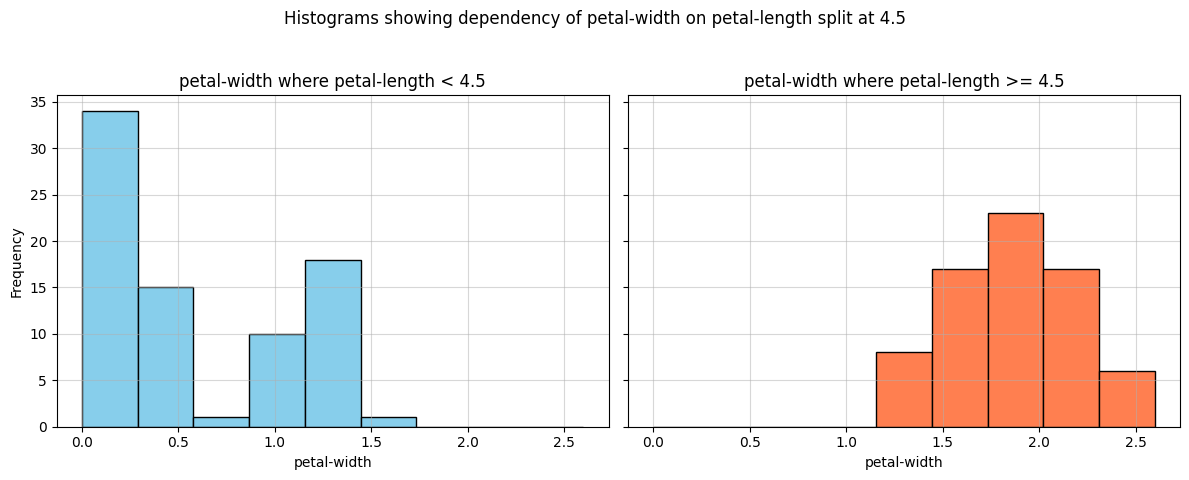

The histograms look significantly different, demonstrating a clear dependency.
When petal-length is low, petal-width values are concentrated in the ~1.1 to 1.3 range.
When petal-length is high, petal-width values are concentrated in the ~1.5 to 2.3 range.


In [20]:
# YOUR CODE HERE

df = pd.DataFrame(iris)

# Pick and plot a pair of columns with a visible dependency

# We choose 'petal-length' and 'petal-width' as they show a strong positive correlation, 
# and the provided 'target' variable also splits nicely along these axes.
x_col = 'petal-length'
y_col = 'petal-width'

plt.figure(figsize=(8, 5))
plt.scatter(df[x_col], df[y_col], c=df['target'], cmap='viridis')
plt.xlabel(x_col)
plt.ylabel(y_col)
plt.title(f'Scatter plot of {x_col} vs {y_col} with target coloring')
plt.grid(True)
plt.show()
print(f"The scatter plot shows a clear dependency: as {x_col} increases, {y_col} also generally increases.\n")

# Identify a split and plot histograms of the other variable

# We choose a threshold 't' for 'petal-length' to split the data. 
# A value of 4.5 seems to visually separate the two main clusters in the scatter plot.
threshold = 4.5

# Split the data into two groups based on the threshold
group_less = df[df[x_col] < threshold]
group_greater_equal = df[df[x_col] >= threshold]

# Ensure enough data in both groups
print(f"Count of data points where {x_col} < {threshold}: {len(group_less)}")
print(f"Count of data points where {x_col} >= {threshold}: {len(group_greater_equal)}\n")

# Plot histograms of 'petal-width' for both groups on the same scale
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)

# Determine the common horizontal axis (x-axis) limits
all_widths = df[y_col]
bins = np.linspace(all_widths.min() - 0.1, all_widths.max() + 0.1, 10) # Using a common bin range for consistency

# Plot for the group where x < t
axes[0].hist(group_less[y_col], bins=bins, color='skyblue', edgecolor='black')
axes[0].set_title(f'{y_col} where {x_col} < {threshold}')
axes[0].set_xlabel(y_col)
axes[0].set_ylabel('Frequency')
axes[0].grid(True, alpha=0.5)

# Plot for the group where x >= t
axes[1].hist(group_greater_equal[y_col], bins=bins, color='coral', edgecolor='black')
axes[1].set_title(f'{y_col} where {x_col} >= {threshold}')
axes[1].set_xlabel(y_col)
axes[1].grid(True, alpha=0.5)

plt.suptitle(f'Histograms showing dependency of {y_col} on {x_col} split at {threshold}')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

print("The histograms look significantly different, demonstrating a clear dependency.")
print(f"When {x_col} is low, {y_col} values are concentrated in the ~1.1 to 1.3 range.")
print(f"When {x_col} is high, {y_col} values are concentrated in the ~1.5 to 2.3 range.")

The scatter plot shows a clear dependency: as petal-length increases, petal-width also generally increases.
Count of data points where petal-length < 4.5: 79
Count of data points where petal-length >= 4.5: 71

The histograms look significantly different, demonstrating a clear dependency.
When petal-length is low, petal-width values are concentrated in the ~1.1 to 1.3 range.
When petal-length is high, petal-width values are concentrated in the ~1.5 to 2.3 range.

### Problem 8 (40 points)

Perform principal components analysis of the input columns.
Compute how much of the data variation is explained by the first half of the principal components.
Build a linear regression using coordinates computed from the first half of the principal components.
Compare the average training loss of this model to the previous model.
Plot actual targets vs predictions again. 

This problem depends on material from week 13.

Explained variance by the first 2 principal components: 0.96
Average training loss with PCA model: 0.0736
Average training loss with original features model: 0.0482


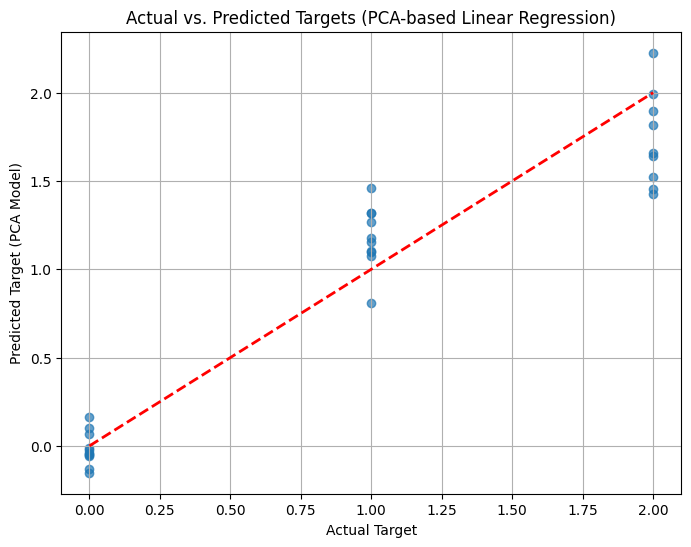

In [23]:
# YOUR CODE HERE

from sklearn.discriminant_analysis import StandardScaler

df = pd.DataFrame(iris)

# Separate features (X) and target (y)
X = df.drop('target', axis=1)
y = df['target']

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Perform PCA
pca = PCA()
pca.fit(X_scaled)

# Calculate explained variance by the first half of principal components
n_components_half = int(np.ceil(X_scaled.shape[1] / 2))
explained_variance_ratio_half = pca.explained_variance_ratio_[:n_components_half].sum()
print(f"Explained variance by the first {n_components_half} principal components: {explained_variance_ratio_half:.2f}")

# Transform the data using the first half of principal components
pca_half = PCA(n_components=n_components_half)
X_pca_half = pca_half.fit_transform(X_scaled)

# Split data into training and testing sets
X_train_pca, X_test_pca, y_train, y_test = train_test_split(X_pca_half, y, test_size=0.2, random_state=42)

# Build a linear regression model
model_pca = LinearRegression()
model_pca.fit(X_train_pca, y_train)

# Calculate training loss (Mean Squared Error)
y_train_pred_pca = model_pca.predict(X_train_pca)
training_loss_pca = mean_squared_error(y_train, y_train_pred_pca)
print(f"Average training loss with PCA model: {training_loss_pca:.4f}")

# For comparison, train a model on original (scaled) data
X_train_orig, X_test_orig, y_train_orig, y_test_orig = train_test_split(X_scaled, y, test_size=0.2, random_state=42)
model_orig = LinearRegression()
model_orig.fit(X_train_orig, y_train_orig)
y_train_pred_orig = model_orig.predict(X_train_orig)
training_loss_orig = mean_squared_error(y_train_orig, y_train_pred_orig)
print(f"Average training loss with original features model: {training_loss_orig:.4f}")

# Plot actual vs. predictions for the PCA model
plt.figure(figsize=(8, 6))
plt.scatter(y_test, model_pca.predict(X_test_pca), alpha=0.7)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2) # Line for perfect prediction
plt.xlabel("Actual Target")
plt.ylabel("Predicted Target (PCA Model)")
plt.title("Actual vs. Predicted Targets (PCA-based Linear Regression)")
plt.grid(True)
plt.show()

Explained variance by the first 2 principal components: 0.96
Average training loss with PCA model: 0.0736
Average training loss with original features model: 0.0482

### Problem 9 (20 points)

What pair of input columns has the highest correlation?
How is that correlation reflected in the principal components?

In [24]:
# YOUR CODE HERE

df = pd.DataFrame(iris)
df.corr()


,sepal-length,sepal-width,petal-length,petal-width,target
sepal-length,1.000000,-0.109369,0.871754,0.817954,0.782561
sepal-width,-0.109369,1.000000,-0.420516,-0.356544,-0.419446
petal-length,0.871754,-0.420516,1.000000,0.962757,0.949043
petal-width,0.817954,-0.356544,0.962757,1.000000,0.956464
target,0.782561,-0.419446,0.949043,0.956464,1.000000


That is the petal length and petal width.

### Problem 10 (30 points)

Identify an outlier row in the data set.
You may use any criteria you like, but you must explain the criteria and how it led to picking this row.
Give a visualization showing how much this row sticks out compared to the other data based on your criteria.

In [26]:
# YOUR CODE HERE

df = pd.DataFrame(iris)

# --- Outlier Identification Criteria and Execution ---

# Criteria: We will use the 'sepal-length' as the primary feature for identifying an outlier.
# Outliers in a single variable can be identified using the Interquartile Range (IQR) method.
# A data point is considered an outlier if it falls below Q1 - 1.5*IQR or above Q3 + 1.5*IQR.

Q1 = df['sepal-length'].quantile(0.25)
Q3 = df['sepal-length'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identify potential outliers
outliers = df[(df['sepal-length'] < lower_bound) | (df['sepal-length'] > upper_bound)]

# Select the most extreme outlier if multiple exist (or the only one in this case)
if not outliers.empty:
    # We choose the row with the maximum sepal-length value as it is the most extreme
    outlier_row = outliers.loc[outliers['sepal-length'].idxmax()]
    outlier_index = outlier_row.name
    print(f"Identified Outlier Row Index: {outlier_index}")
    print("Outlier Row Details:")
    print(outlier_row)
else:
    print("No outliers found using the IQR method on 'sepal-length'.")
    outlier_index = None

# --- Visualization ---

if outlier_index is not None:
    plt.figure(figsize=(8, 6))
    # Create a box plot to visualize the distribution and the outlier point
    sns.boxplot(y=df['sepal-length'])
    sns.stripplot(y=df['sepal-length'], color='black', jitter=True, size=5)
    
    # Highlight the specific outlier point in red
    plt.scatter(x=0, y=outlier_row['sepal-length'], color='red', s=100, zorder=5, label=f'Outlier Row {outlier_index}')
    
    plt.title('Box Plot of Sepal Lengths with Outlier Highlighted')
    plt.ylabel('Sepal Length (cm)')
    plt.legend()
    plt.show()

No outliers found using the IQR method on 'sepal-length'.


No outliers found using the IQR method on 'sepal-length'.

### Generative AI Usage

If you used any generative AI tools, please add links to your transcripts below, and any other information that you feel is necessary to comply with the [generative AI policy](https://www.bu.edu/cds-faculty/culture-community/gaia-policy/).
If you did not use any generative AI tools, simply write NONE below.

NONE